In [3]:
import numpy as np
import numpy.random as nprand
import matplotlib.pyplot as plt
from scipy.stats import gamma
import matplotlib.colors as mcolors
from matplotlib.colors import PowerNorm

In [3]:
### CODE 1D

def f_1d(t,a,b):
    return 0.5*5*(t+a*np.sin(b*t))**2 
def f_1d_deriv(t,a,b):
    return 5*(t+a*np.sin(b*t))*(1+a*b*np.cos(b*t))
def f_1d_hess(t,a,b):
    return 5*(1+a*b*np.cos(b*t))*(1+a*b*np.cos(b*t)) - 5*(t+a*np.sin(b*t))*(a*b*b*np.sin(b*t))
### CODE 2D

def h(r):
    return 0.5*r**2  # décroissance radiale
def h_prime(r):  
    return r
def g(u, v,nb_f,a,b):
    # nb_f = 10
    # a,c = nprand.uniform(0,15,nb_f), nprand.uniform(0,15,nb_f)
    # b,d = nprand.uniform(-25,25,nb_f), nprand.uniform(-25,25,nb_f)
    return_var = 0
    for i in range(nb_f):
        return_var += a[i]*np.sin(b[i]*u)**2 + c[i]*np.cos(d[i]*v)**2
    return return_var/nb_f + 1 # dépend uniquement de la direction

def grad_g(u, v,nb_f,a,b):
    # nb_f = 10

    return_var = np.zeros(2)
    for i in range(nb_f):
        return_var[0] +=  2*b[i]*a[i]*np.sin(b[i]*u)*np.cos(b[i]*u) 
        return_var[1] += - 2*d[i]*c[i]*np.cos(d[i]*u)*np.sin(d[i]*u)
    return return_var/nb_f # dépend uniquement de la direction


def f(x, y,nb_f,a,b):
    r = np.sqrt(x**2 + y**2)
    # éviter la division par zéro
    u = np.where(r != 0, x/r, 0.0)
    v = np.where(r != 0, y/r, 0.0)
    return h(r) * g(u, v,nb_f,a,b)

def grad_f(x, y,nb_f,a,b):
    r = np.sqrt(x**2 + y**2)
    # éviter la division par zéro
    u = np.where(r != 0, x/r, 0.0)
    v = np.where(r != 0, y/r, 0.0)
    return np.array([u,v])/r * g(u, v,nb_f,a,b) + h(r)* grad_g(u,v,nb_f,a,b)

Text(0.5, 0, '')

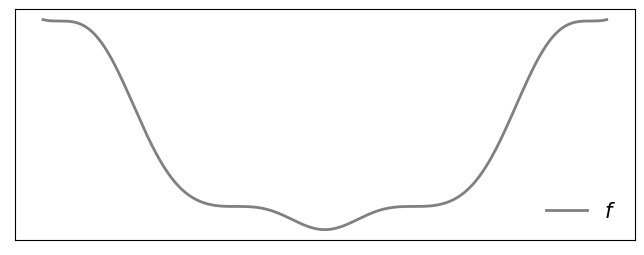

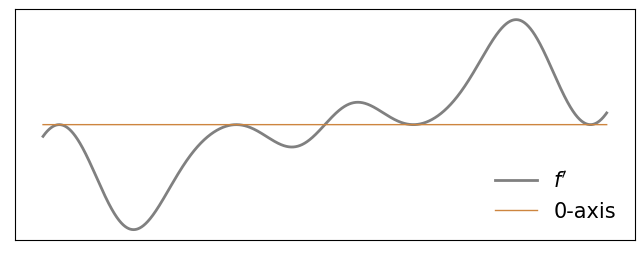

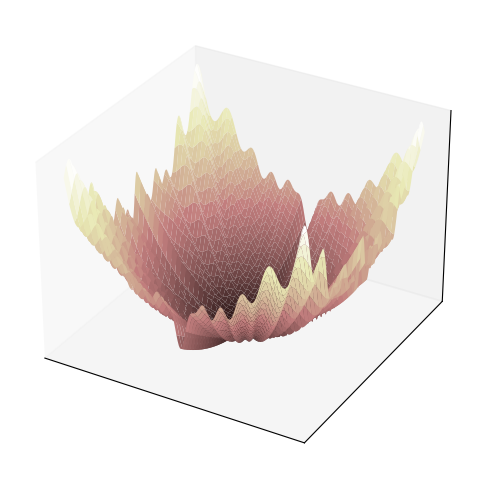

In [4]:
### --- #### ATTENTION, 1d et 2d mélangé avec définition foireuses de a et b. <- Toujours vrai ?
x_min = -2
x_max = 2
nb_step = 1000000
tt = np.linspace(x_min, x_max, nb_step)
fontsize = 15
# === Figure 1 : f_1d ===
a_1d = 0.2
b_1d = 5
plt.figure(figsize=(8, 3))
plt.plot(tt, f_1d(tt, a_1d, b_1d), lw=2, color="grey",label=r"$f$")
plt.xticks([])
plt.yticks([])
plt.legend(loc=4,edgecolor=(1,1,1),fontsize=fontsize)
# plt.title("f_1d")
plt.savefig("figures/f_sqc.pdf", dpi=300, bbox_inches="tight")

# === Figure 2 : dérivée ===
plt.figure(figsize=(8, 3))
plt.plot(tt, f_1d_deriv(tt, a_1d, b_1d), lw=2, zorder=0, color="grey",label=r"$f'$")
plt.plot(tt, np.zeros(nb_step), color="peru", lw=1, zorder=1,label="0-axis")

plt.xticks([])
plt.yticks([])
plt.legend(loc=4,edgecolor=(1,1,1),fontsize= fontsize)
plt.savefig("figures/f'_sqc.pdf", dpi=300, bbox_inches="tight")

# === Figure 3 : surface 3D ===
from mpl_toolkits.mplot3d import Axes3D
nb_f = 10
a,c = nprand.uniform(0,15,nb_f), nprand.uniform(0,15,nb_f)
b,d = nprand.uniform(-25,25,nb_f), nprand.uniform(-25,25,nb_f)
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y,)
Z = f(X, Y,nb_f,a,b)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="pink", edgecolor="none")


ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
# plt.savefig("figures/3d_sqc.pdf", dpi=300, bbox_inches="tight")

In [6]:
# --- # Test of GEOMETRICAL CONDITIONS on 1d function # --- #
pl = 0.5*f_1d_deriv(tt,a_1d,b_1d)**2/f_1d(tt,a_1d,b_1d)
rsi = np.abs(f_1d_deriv(tt,a_1d,b_1d)/(tt))
qg =  2*f_1d(tt,a_1d,b_1d)/tt**2
pl_const = np.min(pl)
rsi_const  = np.min(rsi)
qg_upp = np.max(qg)
qg_inf = np.min(qg)
arg_inf = np.argmin(rsi_const)
L_const = np.max(np.abs(f_1d_hess(tt, a_1d, b_1d)))

functions_values =f_1d(tt, a_1d, b_1d)


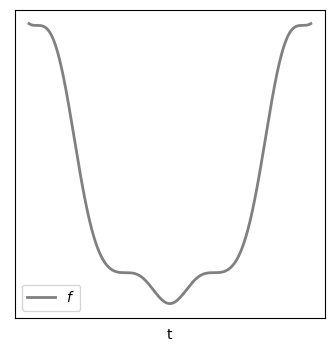

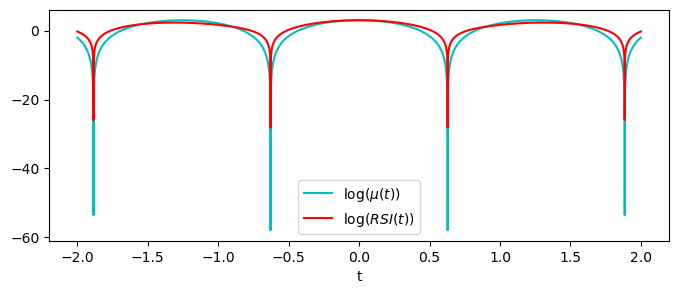

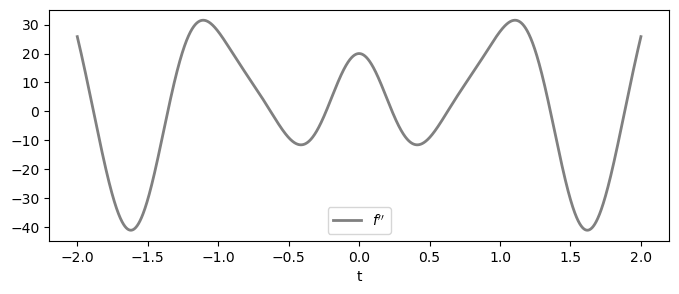

In [9]:

interv = np.arange(arg_inf-10,arg_inf+10)
# plt.figure(figsize=(10,5))
# plt.plot(tt[interv],np.log(pl_const[interv]),color="c",label="PL")
# plt.plot(tt[interv],np.log(rsi_const[interv]),color = "r",label="RSI")
plt.figure(figsize=(4, 4))
plt.plot(tt, functions_values, lw=2, color="grey",label=r"$f$")
# plt.plot(tt,0.5*qg_upp*tt**2, label = "quadratic UB")
# plt.plot(tt,0.5*qg_inf*tt**2, label = "quadratic LB")
# plt.xticks([])
plt.xticks([])
plt.yticks([])
plt.xlabel("t")
plt.legend(loc=4,edgecolor=(1,1,1),fontsize=fontsize)
plt.legend()
plt.savefig("figures/f_1d_graph.pdf", dpi=300, bbox_inches="tight")
plt.figure(figsize=(8,3))
plt.plot(tt,np.log(pl),color="c",label=r'$\log(\mu(t))$')
plt.plot(tt,np.log(rsi),color = "r",label=r"$\log(RSI(t))$")
plt.yticks([0,-20,-40,-60])
plt.xlabel("t")
plt.legend()
plt.savefig("figures/f_1d_rsi_vs_pl.pdf", dpi=300, bbox_inches="tight")
plt.figure(figsize=(8,3))
plt.plot(tt, f_1d_hess(tt, a_1d, b_1d), lw=2, color="grey",label=r"$f''$")
plt.xlabel("t")
plt.legend()
plt.savefig("figures/f_1d_rsi_vs_pl.pdf", dpi=300, bbox_inches="tight")

3.0636159657412363 19.99999999166665
243.9757299620425


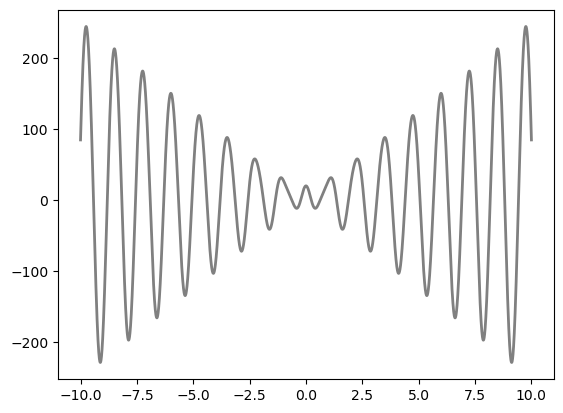

In [30]:
print(np.min(qg),np.max(qg))
print(np.max(np.abs(f_1d_hess(tt, a_1d, b_1d))))
plt.plot(tt, f_1d_hess(tt, a_1d, b_1d), lw=2, color="grey",label=r"$f$")

Nest :  2.666050731972553e-13 GD :  4.775415625956973e-14
5.58286637393638


243.9757299620425

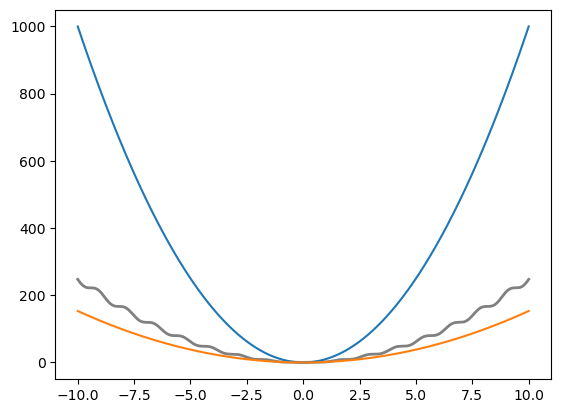

In [50]:
### Code ébauché, qu'il faudrat faire pour calculer borne sup/inf quadratique

# tt = np.linspace(-10, 10, nb_step)
L = np.max(np.abs(f_1d_hess(tt, a_1d, b_1d)))
print("Nest : ", (qg_inf/qg_upp)**(0.25) * np.sqrt(np.min(pl_const)/L), "GD : ", np.sqrt(np.min(pl_const)*qg_inf)/L)
print(((qg_inf/qg_upp)**(0.25) * np.sqrt(np.min(pl_const)/L))/(np.sqrt(np.min(pl_const)*qg_inf)/L))
plt.plot(tt, f_1d(tt, a_1d, b_1d), lw=2, color="grey",label=r"$f$")
# plt.plot(tt, f_1d_hess(tt, a_1d, b_1d), lw=2, color="grey",label=r"$f$")
plt.plot(tt,0.5*qg_upp*tt**2)
plt.plot(tt,0.5*qg_inf*tt**2)
np.max(np.abs( f_1d_hess(tt, a_1d, b_1d)))

In [37]:
L

243.9757299620425

In [100]:
#---# Test of quasar convex #---#
gamma = np.linspace(1*10**(-15),2.4*10**(-13),100)
max_val_acc = 0
max_val_gd = 0
L = np.abs(f_1d_hess(tt,a_1d,b_1d)).max()
vec_mu=np.empty(100)
k = 0
for i in gamma:
    sqc_mu_cst = -2*(f_1d(tt,a_1d,b_1d) - i**(-1)*f_1d_deriv(tt,a_1d,b_1d)*tt)/(tt**2)
    
    print("gamma = ", i, ", mu = ", sqc_mu_cst.min(), ", gamma sqrt mu/L = ",np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L), ", sqrt mu/L = ", (sqc_mu_cst).min()*i/L)
    max_val_acc = np.nanmax([np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L),max_val_acc])
    max_val_gd = np.nanmax([(sqc_mu_cst).min()*i/L,max_val_gd])
    vec_mu[k] = sqc_mu_cst.min()
    k+=1

gamma =  1e-15 , mu =  1186.2691219288292 , gamma sqrt mu/L =  5.3709361518301285e-15 , sqrt mu/L =  2.8846955147035826e-14
gamma =  3.414141414141414e-15 , mu =  343.9220220183662 , gamma sqrt mu/L =  9.873471457131397e-15 , sqrt mu/L =  2.8553427286580025e-14
gamma =  5.8282828282828285e-15 , mu =  199.39453000599894 , gamma sqrt mu/L =  1.2833810289788436e-14 , sqrt mu/L =  2.8259899426124224e-14
gamma =  8.242424242424242e-15 , mu =  139.52897571656257 , gamma sqrt mu/L =  1.5182578798264456e-14 , sqrt mu/L =  2.796637156566843e-14
gamma =  1.0656565656565656e-14 , mu =  106.78734081134473 , gamma sqrt mu/L =  1.7172579184516166e-14 , sqrt mu/L =  2.7672843705212622e-14
gamma =  1.307070707070707e-14 , mu =  86.14037475055822 , gamma sqrt mu/L =  1.8917373422417423e-14 , sqrt mu/L =  2.7379315844756824e-14
gamma =  1.5484848484848483e-14 , mu =  71.93127547193478 , gamma sqrt mu/L =  2.0479729564367566e-14 , sqrt mu/L =  2.7085787984301026e-14
gamma =  1.7898989898989895e-14 , mu =

/tmp/ipykernel_7481/3345977656.py:11: RuntimeWarning: invalid value encountered in sqrt
  print("gamma = ", i, ", mu = ", sqc_mu_cst.min(), ", gamma sqrt mu/L = ",np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L), ", sqrt mu/L = ", (sqc_mu_cst).min()*i/L)
/tmp/ipykernel_7481/3345977656.py:12: RuntimeWarning: invalid value encountered in sqrt
  max_val_acc = np.nanmax([np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L),max_val_acc])


/tmp/ipykernel_7481/1160612044.py:7: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma/np.sqrt(L))[0:],color="r", label ="NM")
/tmp/ipykernel_7481/1160612044.py:21: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma)[0:],color="r", label ="NMO")


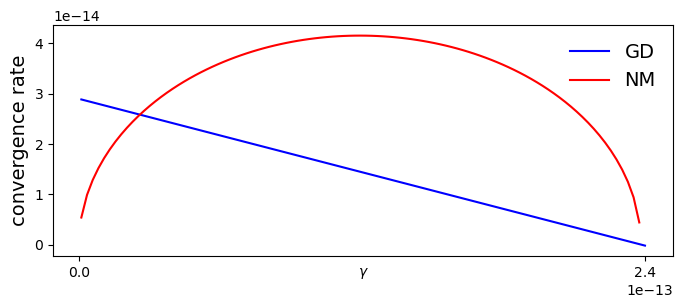

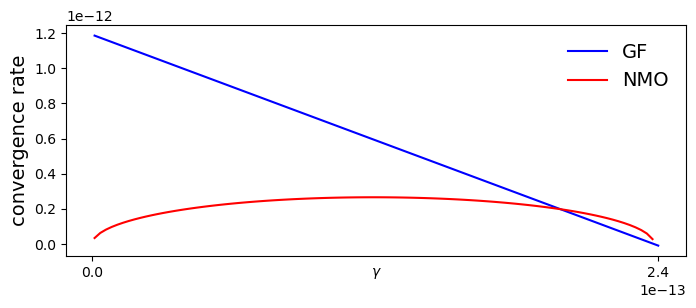

In [126]:
### -- Figure quasar convex -- ###
fontsize = 14
plt.figure(figsize=(8,3))
# plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma/np.sqrt(L))[0:],color="b", label =r'$\gamma \sqrt{\mu/L}$')
# plt.plot(gamma[0:],(vec_mu*gamma/L)[0:],color ="r",label=r'$\gamma\mu/L$')
plt.plot(gamma[0:],(vec_mu*gamma/L)[0:],color ="b",label="GD")
plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma/np.sqrt(L))[0:],color="r", label ="NM")

plt.xlabel(r'$\gamma$',labelpad=-10)
plt.ylabel("convergence rate",fontsize=fontsize)
plt.xticks([0,2.4*10**(-13)])
# plt.yticks([0,1.5*10**(-14),3*10**(-14)])
# plt.yticks([0,2*10**(-14),3*10**(-14),4*10**(-14)])
plt.legend(edgecolor=(1,1,1),fontsize=fontsize)
plt.savefig("figures/sqc_bound.pdf", dpi=300, bbox_inches="tight")

plt.figure(figsize=(8,3))
# plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma)[0:],color="b", label =r'$\gamma \sqrt{\mu}$')
# plt.plot(gamma[0:],(vec_mu*gamma)[0:],color ="r",label=r'$\gamma\mu$')
plt.plot(gamma[0:],(vec_mu*gamma)[0:],color ="b",label="GF")
plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma)[0:],color="r", label ="NMO")

plt.xlabel(r'$\gamma$',labelpad=-10)
plt.ylabel("convergence rate",fontsize=fontsize)
plt.xticks([0,2.4*10**(-13)])
# plt.yticks([0,6*10**(-13)])
plt.legend(edgecolor=(1,1,1),fontsize=fontsize)
plt.savefig("figures/sqc_bound_cont.pdf", dpi=300, bbox_inches="tight")

In [258]:
vec_mu

array([         inf, 587.17821536, 292.33910807, 194.05940564,
       144.91955442, 115.43564369,  95.77970321,  81.73974572,
        71.2097776 ,  63.0198024 ,  56.46782224,  51.10711119,
        46.63985199,  42.85986344,  39.61987325,  36.81188175,
        34.35488919,  32.18695458,  30.25990159,  28.53569628,
        26.98391151,  25.57991576,  24.30355599,  23.13818402,
        22.06992638,  21.08712936,  20.17993211,  19.33993465,
        18.55993701,  17.83373231,  17.15594126,  16.52187867,
        15.92744498,  15.36903758,  14.84347768,  14.34794976,
        13.87995118,  13.43724982,  13.01784853,  12.619955  ,
        12.24195614,  11.88239625,  11.53995827,  11.21344763,
        10.90177838,  10.6039611 ,  10.3190924 ,  10.04634577,
         9.78496358,   9.53425005,   9.29356507,   9.06231871,
         8.83996644,   8.62600483,   8.41996771,   8.22142286,
         8.02996889,   7.84523261,   7.66686655,   7.49454679,
         7.32797102,   7.16685675,   7.01093972,   6.85

In [140]:
pl_const.min(),rsi_const.min()
L = np.abs(f_1d_hess(tt,a_1d,b_1d)).max()
print(L)
print(pl_const.min()/L)
print(rsi_const.min()/(np.sqrt(L)*np.sqrt(5)))
print(rsi_const.min()/((L)))
# print(max_val_acc, max_val_gd)

41.122853898524006
1.7254670134815704e-27
4.153873466328031e-14
1.4484271000683443e-14


-0.01818855586984113 -1.0615151904422056e-16 nan


/tmp/ipykernel_7499/3226292789.py:5: RuntimeWarning: invalid value encountered in sqrt
  print(mu_cst,mu_cst*gamma/L,np.sqrt(mu_cst)*gamma/np.sqrt(L))


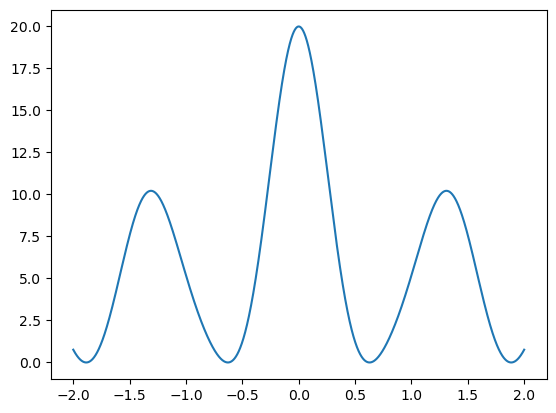

In [263]:
# plt.plot(tt,f_1d_hess(tt,a_1d,b_1d))
#gamma = 1.24*10**(-13) #approximatively best bound inert
gamma = 2.4*10**(-13)
mu_cst = (-(f_1d(tt,a_1d,b_1d) - gamma**(-1)*f_1d_deriv(tt,a_1d,b_1d)*tt)/(tt**2)).min()
print(mu_cst,mu_cst*gamma/L,np.sqrt(mu_cst)*gamma/np.sqrt(L))
plt.plot(tt,rsi_const)

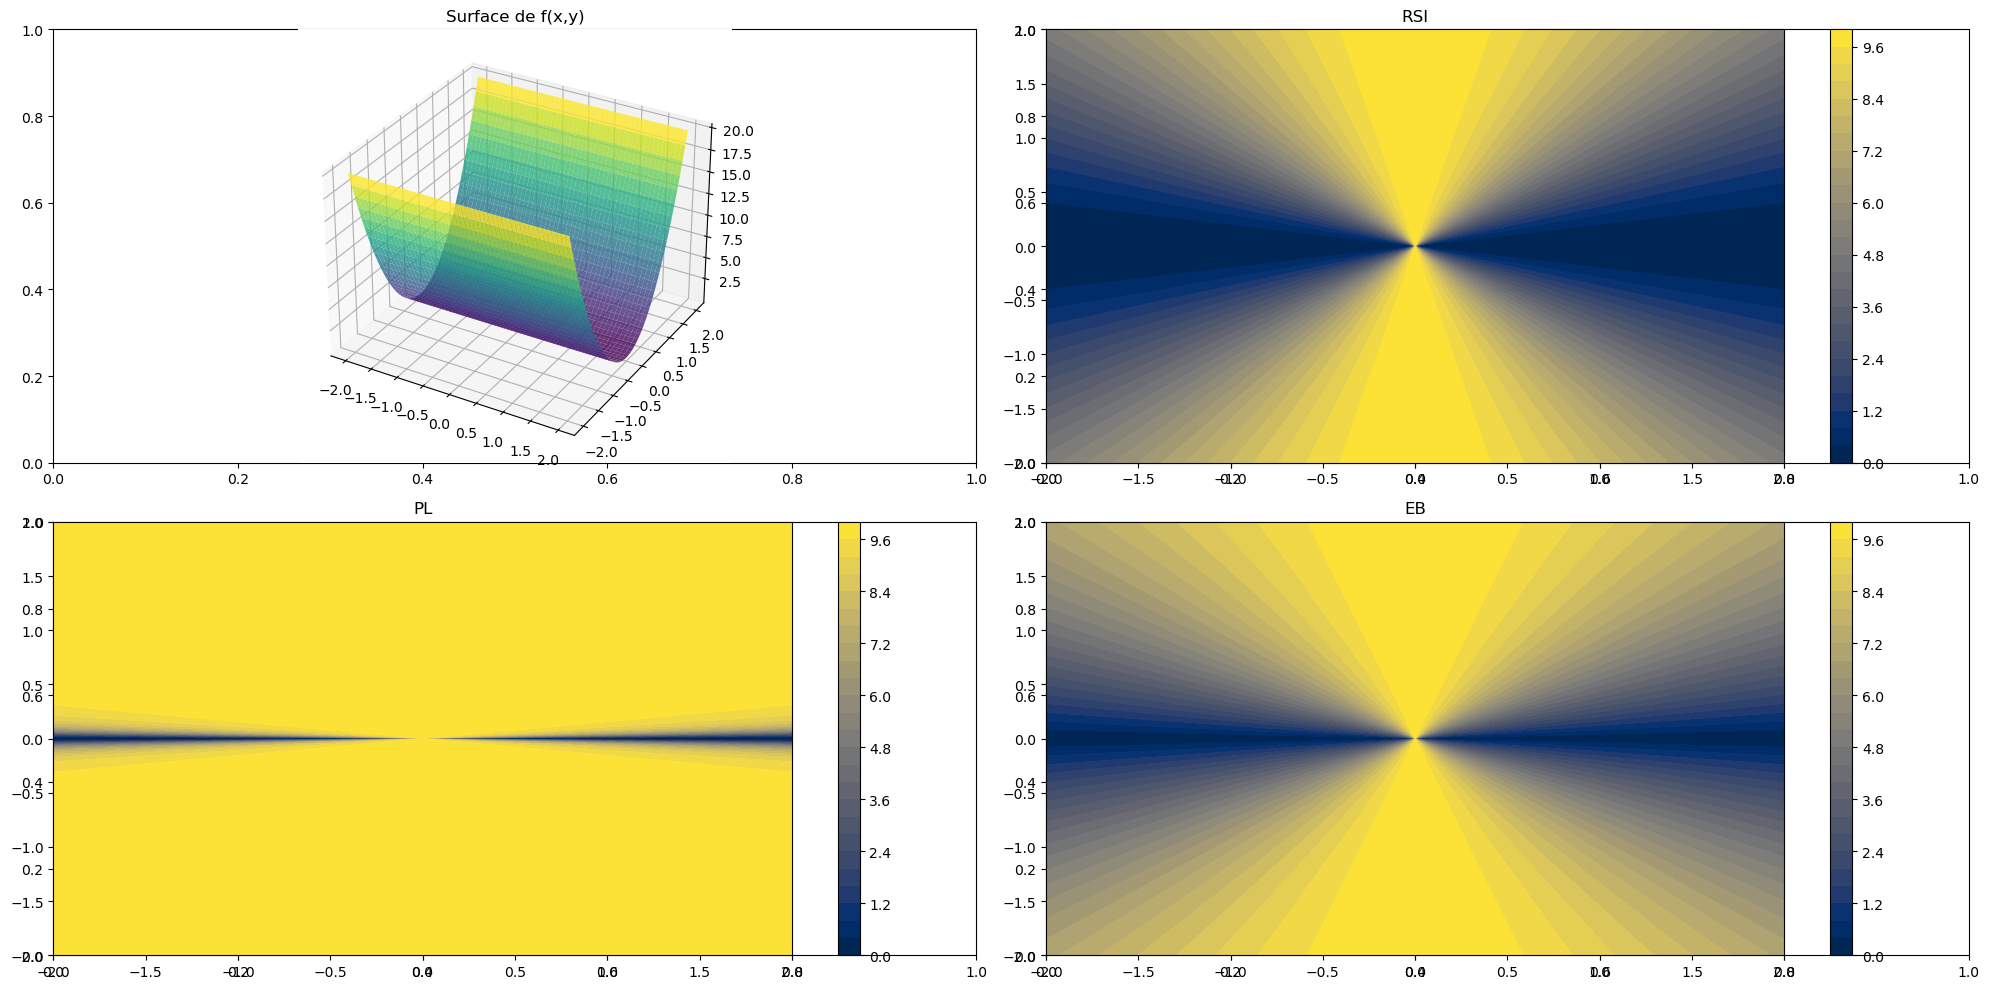

In [5]:
# ---- Test of geometrical cosntant on quadratic function ------#

# --- Fonction quadratique ---
def f(x, y,mu,L):
    return 0.5*mu*x**2 + 0.5*L*y**2  # Hessienne diag(2,4) > 0

# --- Gradient ---
def grad_f(x, y,mu,L):
    return np.array([mu*x, L*y])

# --- Grille de points ---
x_vals = np.linspace(-2, 2, 1000)
y_vals = np.linspace(-2, 2, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
mu = 10**(-2)
L = 10**1
# Valeurs de la fonction
Z = f(X, Y,mu,L)

# Gradient sur la grille
U, V = grad_f(X, Y,mu,L)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / norm_x2[mask]

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

# Surface f(x,y)
ax1 = fig.add_subplot(2,2,1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax1.set_title("Surface de f(x,y)")

ax2 = fig.add_subplot(2,2,2)
im1 = ax2.contourf(X, Y, Q1, levels=30, cmap="cividis")
ax2.set_title("RSI")
fig.colorbar(im1, ax=ax2)

ax3 = fig.add_subplot(2,2,3)
im2 = ax3.contourf(X, Y, Q2, levels=30, cmap="cividis")
ax3.set_title("PL")
fig.colorbar(im2, ax=ax3)

# ax4 = fig.add_subplot(2,2,4)
# ax4.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
# ax4.quiver(X, Y, U, V, color="red")
# ax4.set_title("Champ de gradient de f")
ax4 = fig.add_subplot(2,2,4)
im3 = ax4.contourf(X, Y, Q3, levels=30, cmap="cividis")
ax4.set_title("EB")
fig.colorbar(im3, ax=ax4)

plt.tight_layout()
plt.show()

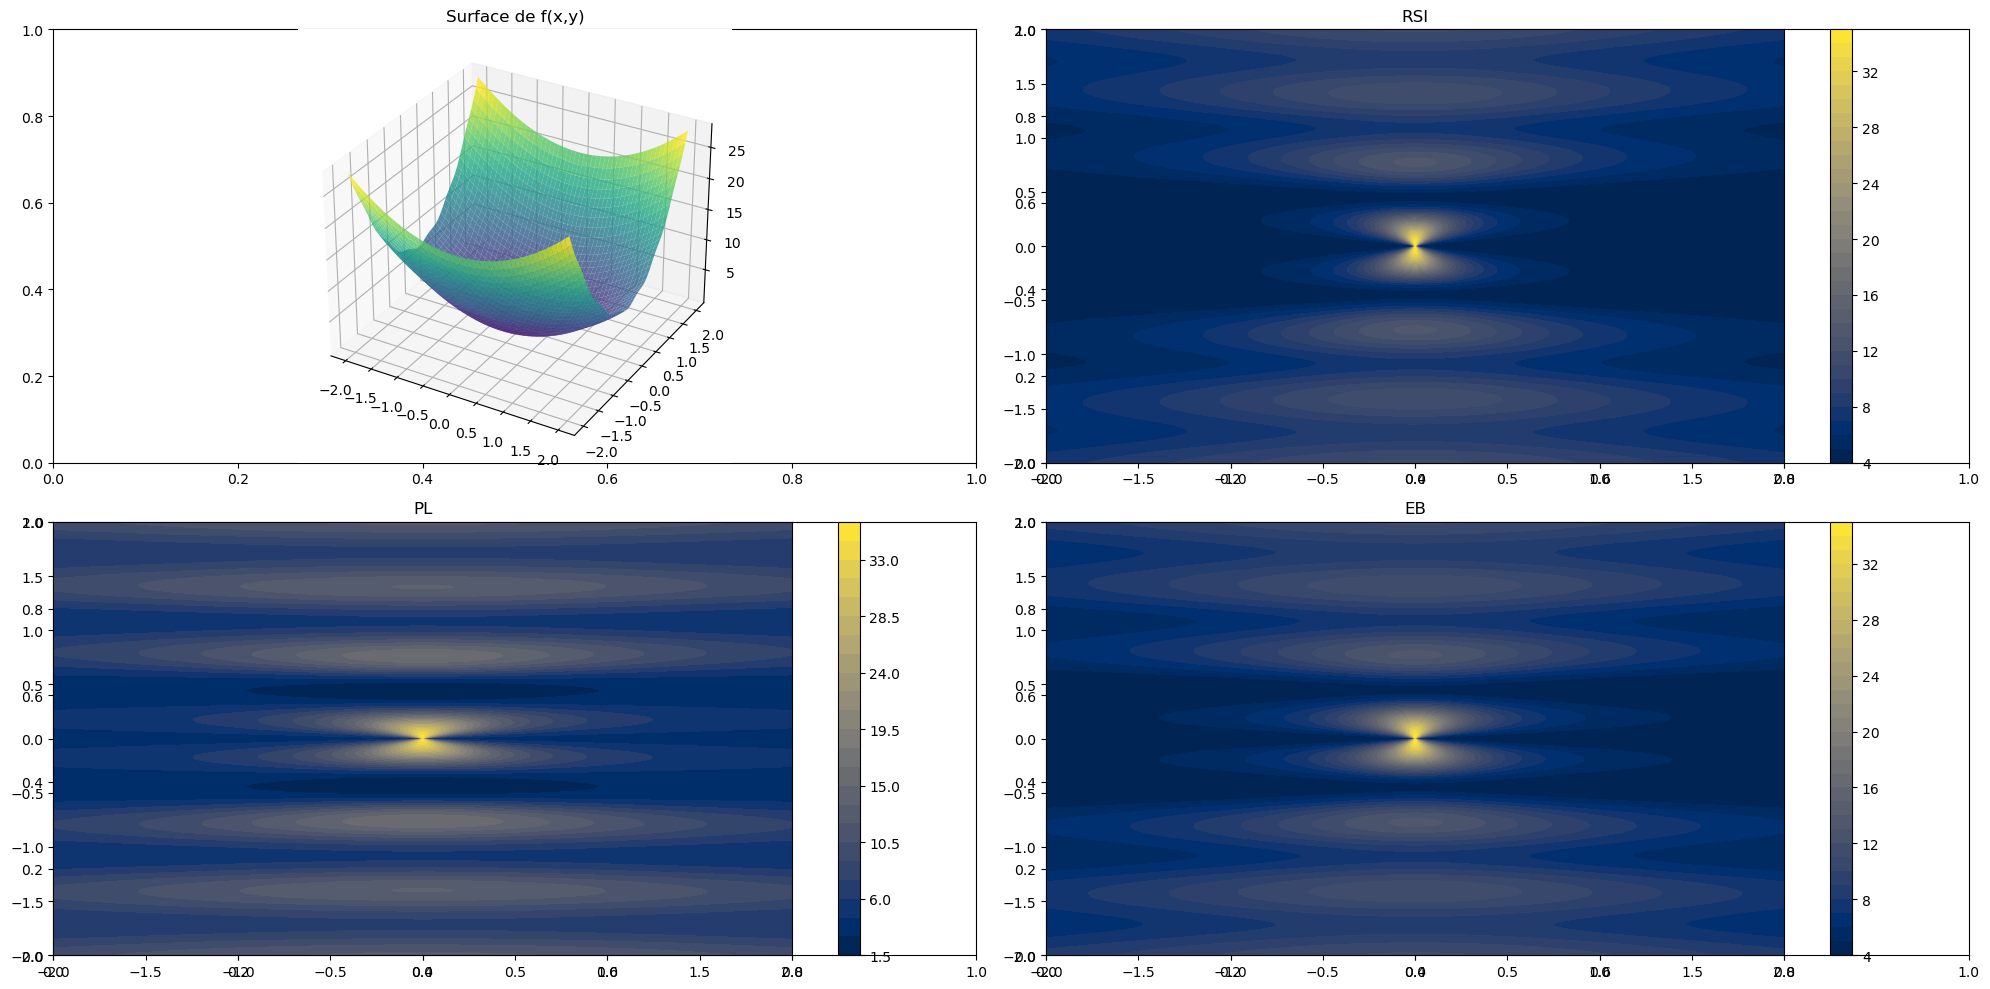

In [66]:
# ---- Test of geometrical cosntant on oscillating quadratic function ------#

# --- Fonction quadratique ---
def f(x, y,mu,L,alpha,beta):
    return 0.5*mu*x**2 + 0.5*L*y**2 + 0.5*alpha*np.sin(beta*y)**2  # Hessienne diag(2,4) > 0

# --- Gradient ---
def grad_f(x, y,mu,L,alpha,beta):
    return np.array([mu*x, L*y + alpha*beta*np.sin(beta*y)*np.cos(beta*y)])

# --- Grille de points ---
x_vals = np.linspace(-2, 2, 1000)
y_vals = np.linspace(-2, 2, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
mu =4*10**(0)
L = 10**1
alpha = 1
beta = 5
# Valeurs de la fonction
Z = f(X, Y,mu,L,alpha,beta)

# Gradient sur la grille
U, V = grad_f(X, Y,mu,L,alpha,beta)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / norm_x2[mask]

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

# Surface f(x,y)
ax1 = fig.add_subplot(2,2,1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax1.set_title("Surface de f(x,y)")

ax2 = fig.add_subplot(2,2,2)
im1 = ax2.contourf(X, Y, Q1, levels=30, cmap="cividis")
ax2.set_title("RSI")
fig.colorbar(im1, ax=ax2)

ax3 = fig.add_subplot(2,2,3)
im2 = ax3.contourf(X, Y, Q2, levels=30, cmap="cividis")
ax3.set_title("PL")
fig.colorbar(im2, ax=ax3)

# ax4 = fig.add_subplot(2,2,4)
# ax4.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
# ax4.quiver(X, Y, U, V, color="red")
# ax4.set_title("Champ de gradient de f")
ax4 = fig.add_subplot(2,2,4)
im3 = ax4.contourf(X, Y, Q3, levels=30, cmap="cividis")
ax4.set_title("EB")
fig.colorbar(im3, ax=ax4)

plt.tight_layout()
plt.show()

In [68]:
print("PL :",Q2.min(), "RSI :", Q1.min(), "RSI :", Q3.min())

PL : 1.575861669609515 RSI : 4.000031060388685 RSI : 4.000151410045469


In [2]:
def f_test(y,L,alpha,beta):
    return 0.5*L*y**2 + 0.5*alpha*np.sin(beta*y)**2
def f_test_deriv(y,L,alpha,beta):
    return L*y + alpha*beta*np.sin(beta*y)*np.cos(beta*y)
tt = np.linspace(0.4,0.5,100000)
L = 10**1
alpha = 1.835
beta = 5
print("distance from zero: ",np.abs(f_test_deriv(tt,L,alpha,beta)).min())

plt.plot(tt,f_test_deriv(tt,L,alpha,beta))
plt.plot(tt,f_test(tt,L,alpha,beta))
plt.plot(tt,np.zeros(np.shape(tt)[0]))

NameError: name 'np' is not defined

PL : 0.0002444157264647179 RSI : 0.061567549314323976 EB : 0.06156760881493187


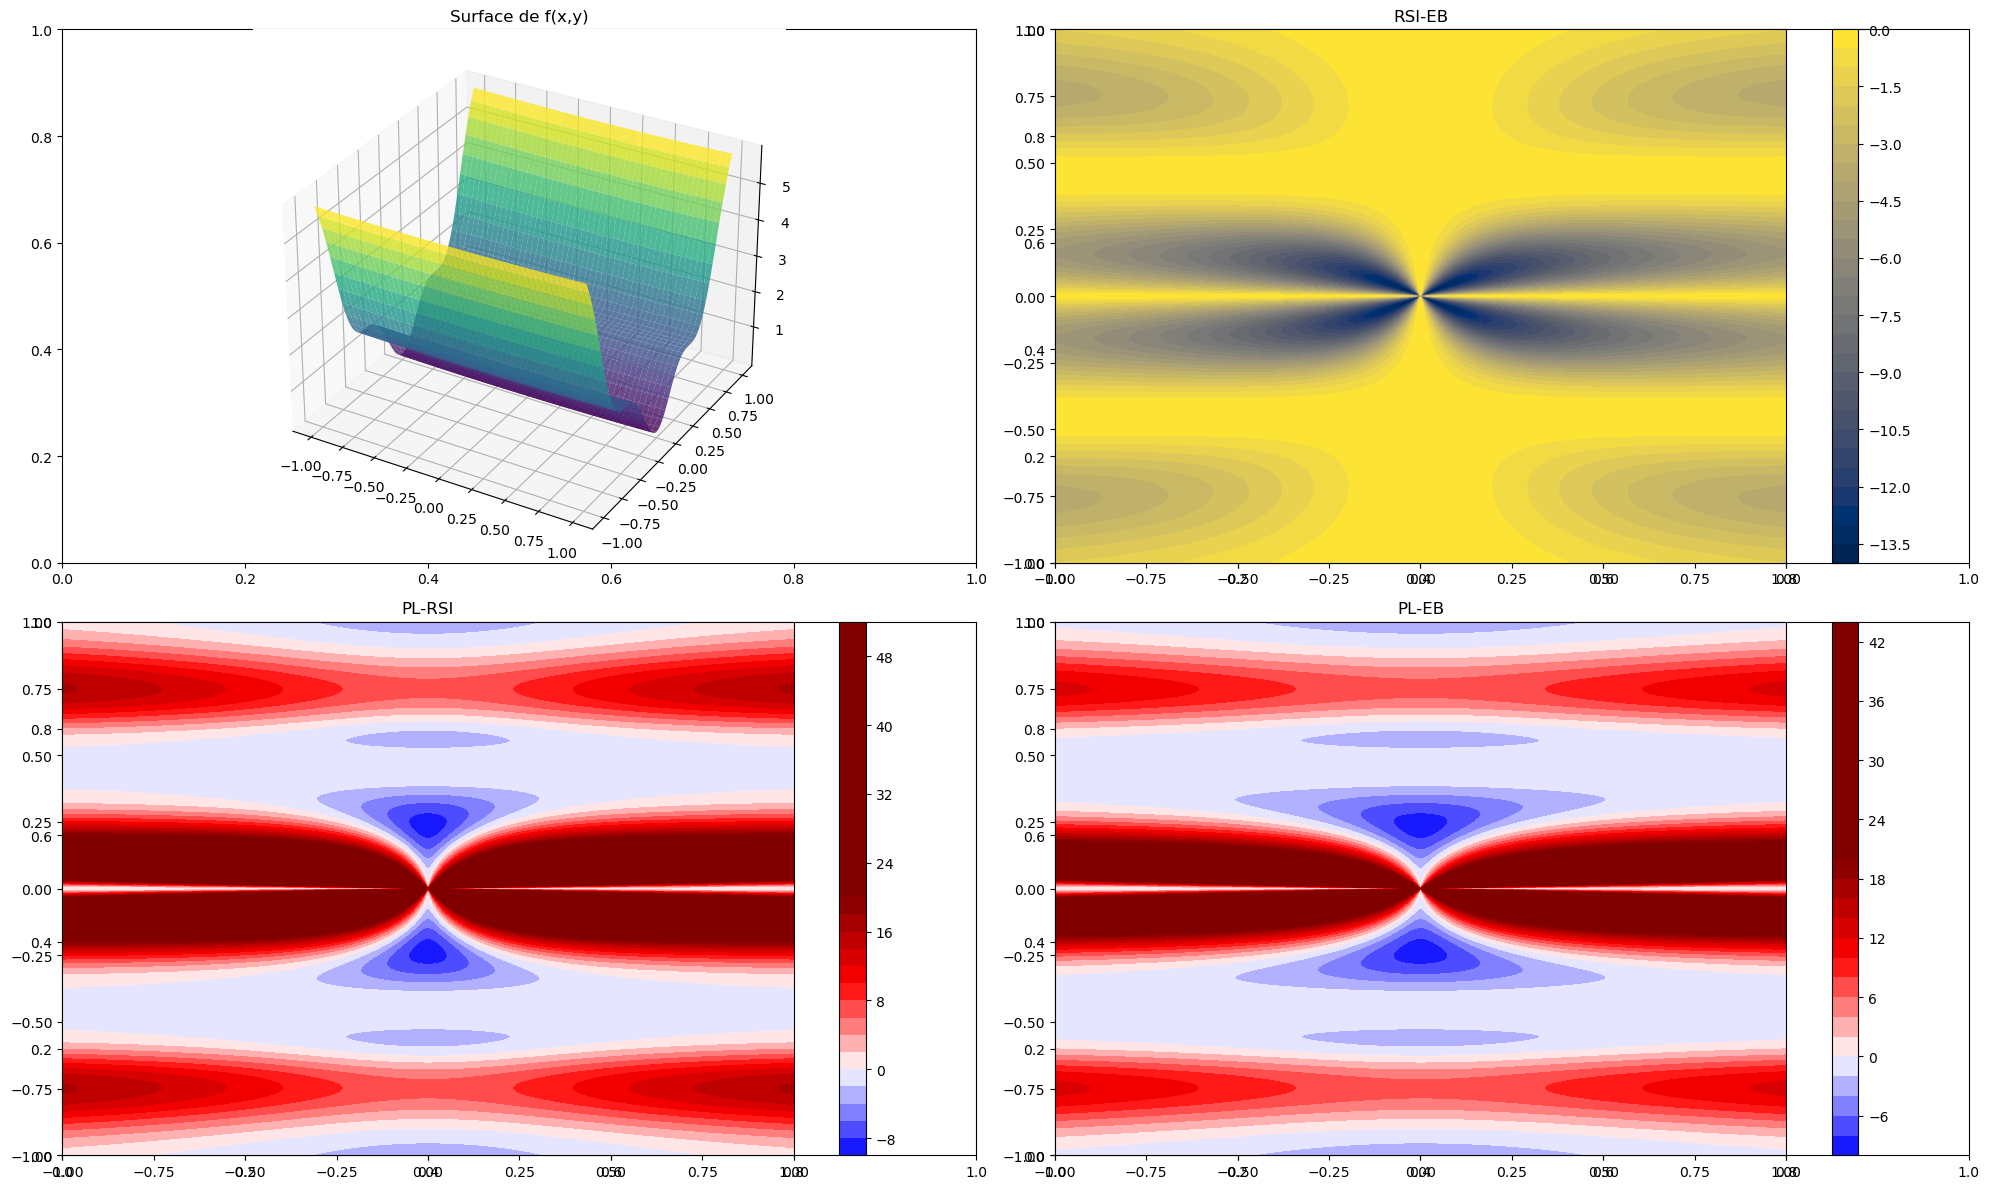

In [4]:
# ---- Test of geometrical cosntant on oscillating quadratic function ------#
# -- Difference between conditions --#
import matplotlib.colors as mcolors
# --- Fonction quadratique ---
def f(x, y,mu,L,alpha,beta):
    return 0.5*mu*x**2 + 0.5*L*y**2 + 0.5*alpha*np.sin(beta*y)**2  # Hessienne diag(2,4) > 0

# --- Gradient ---
def grad_f(x, y,mu,L,alpha,beta):
    return np.array([mu*x, L*y + alpha*beta*np.sin(beta*y)*np.cos(beta*y)])

# --- Grille de points ---
x_vals = np.linspace(-1, 1, 1000)
y_vals = np.linspace(-1, 1, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
mu = 1*10**(-1)
L = 10**1
alpha = 1.83
beta = 5
# Valeurs de la fonction
Z = f(X, Y,mu,L,alpha,beta)

# Gradient sur la grille
U, V = grad_f(X, Y,mu,L,alpha,beta)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / norm_x2[mask]

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])

print("PL :",Q2.min(), "RSI :", Q1.min(), "EB :", Q3.min())
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

# Surface f(x,y)
ax1 = fig.add_subplot(2,2,1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax1.set_title("Surface de f(x,y)")

ax2 = fig.add_subplot(2,2,2)
Z = np.array([-20,0,20])
divnorm = mcolors.TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
im1 = ax2.contourf(X, Y, Q1-Q3, levels=30, cmap="cividis")
ax2.set_title("RSI-EB")
fig.colorbar(im1, ax=ax2)

ax3 = fig.add_subplot(2,2,3)
im2 = ax3.contourf(X, Y, Q2-Q1, levels=30, cmap="seismic", norm=divnorm, origin="lower")
## -- Other possible representation :
#im2 = ax3.contourf(X, Y, Q2/Q1, levels=30, cmap="cividis")
## -- But use logarithmic scale for color --##
ax3.set_title("PL-RSI")
fig.colorbar(im2, ax=ax3)

# ax4 = fig.add_subplot(2,2,4)
# ax4.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
# ax4.quiver(X, Y, U, V, color="red")
# ax4.set_title("Champ de gradient de f")
ax4 = fig.add_subplot(2,2,4)
im3 = ax4.contourf(X, Y, Q2-Q3, levels=30, cmap="seismic", norm=divnorm, origin="lower")
ax4.set_title("PL-EB")
fig.colorbar(im3, ax=ax4)

plt.tight_layout()
plt.show()

In [8]:
((Q3.min())**2)/10

0.0003790570455188476

distance from zero:  0.0


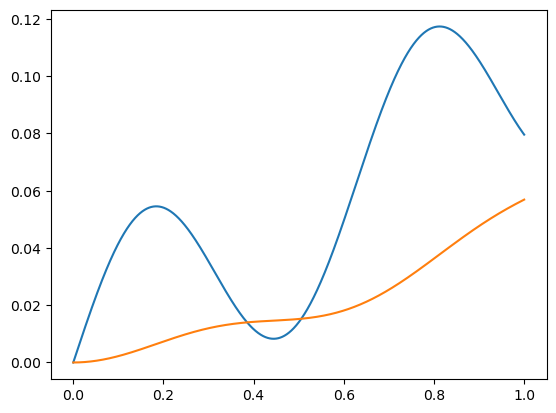

In [16]:
def f_test(y,L,alpha,beta):
    return 0.5*L*y**2 + 0.5*alpha*np.sin(beta*y)**2
def f_test_deriv(y,L,alpha,beta):
    return L*y + alpha*beta*np.sin(beta*y)*np.cos(beta*y)
tt = np.linspace(0,1,10000)
L = 10**(-1)
alpha = 0.015
beta = 5
print("distance from zero: ",np.abs(f_test_deriv(tt,L,alpha,beta)).min())

plt.plot(tt,f_test_deriv(tt,L,alpha,beta))
plt.plot(tt,f_test(tt,L,alpha,beta))

PL : 0.002346666735908909 RSI : 0.018537841442377134 EB : 0.018538729251466594


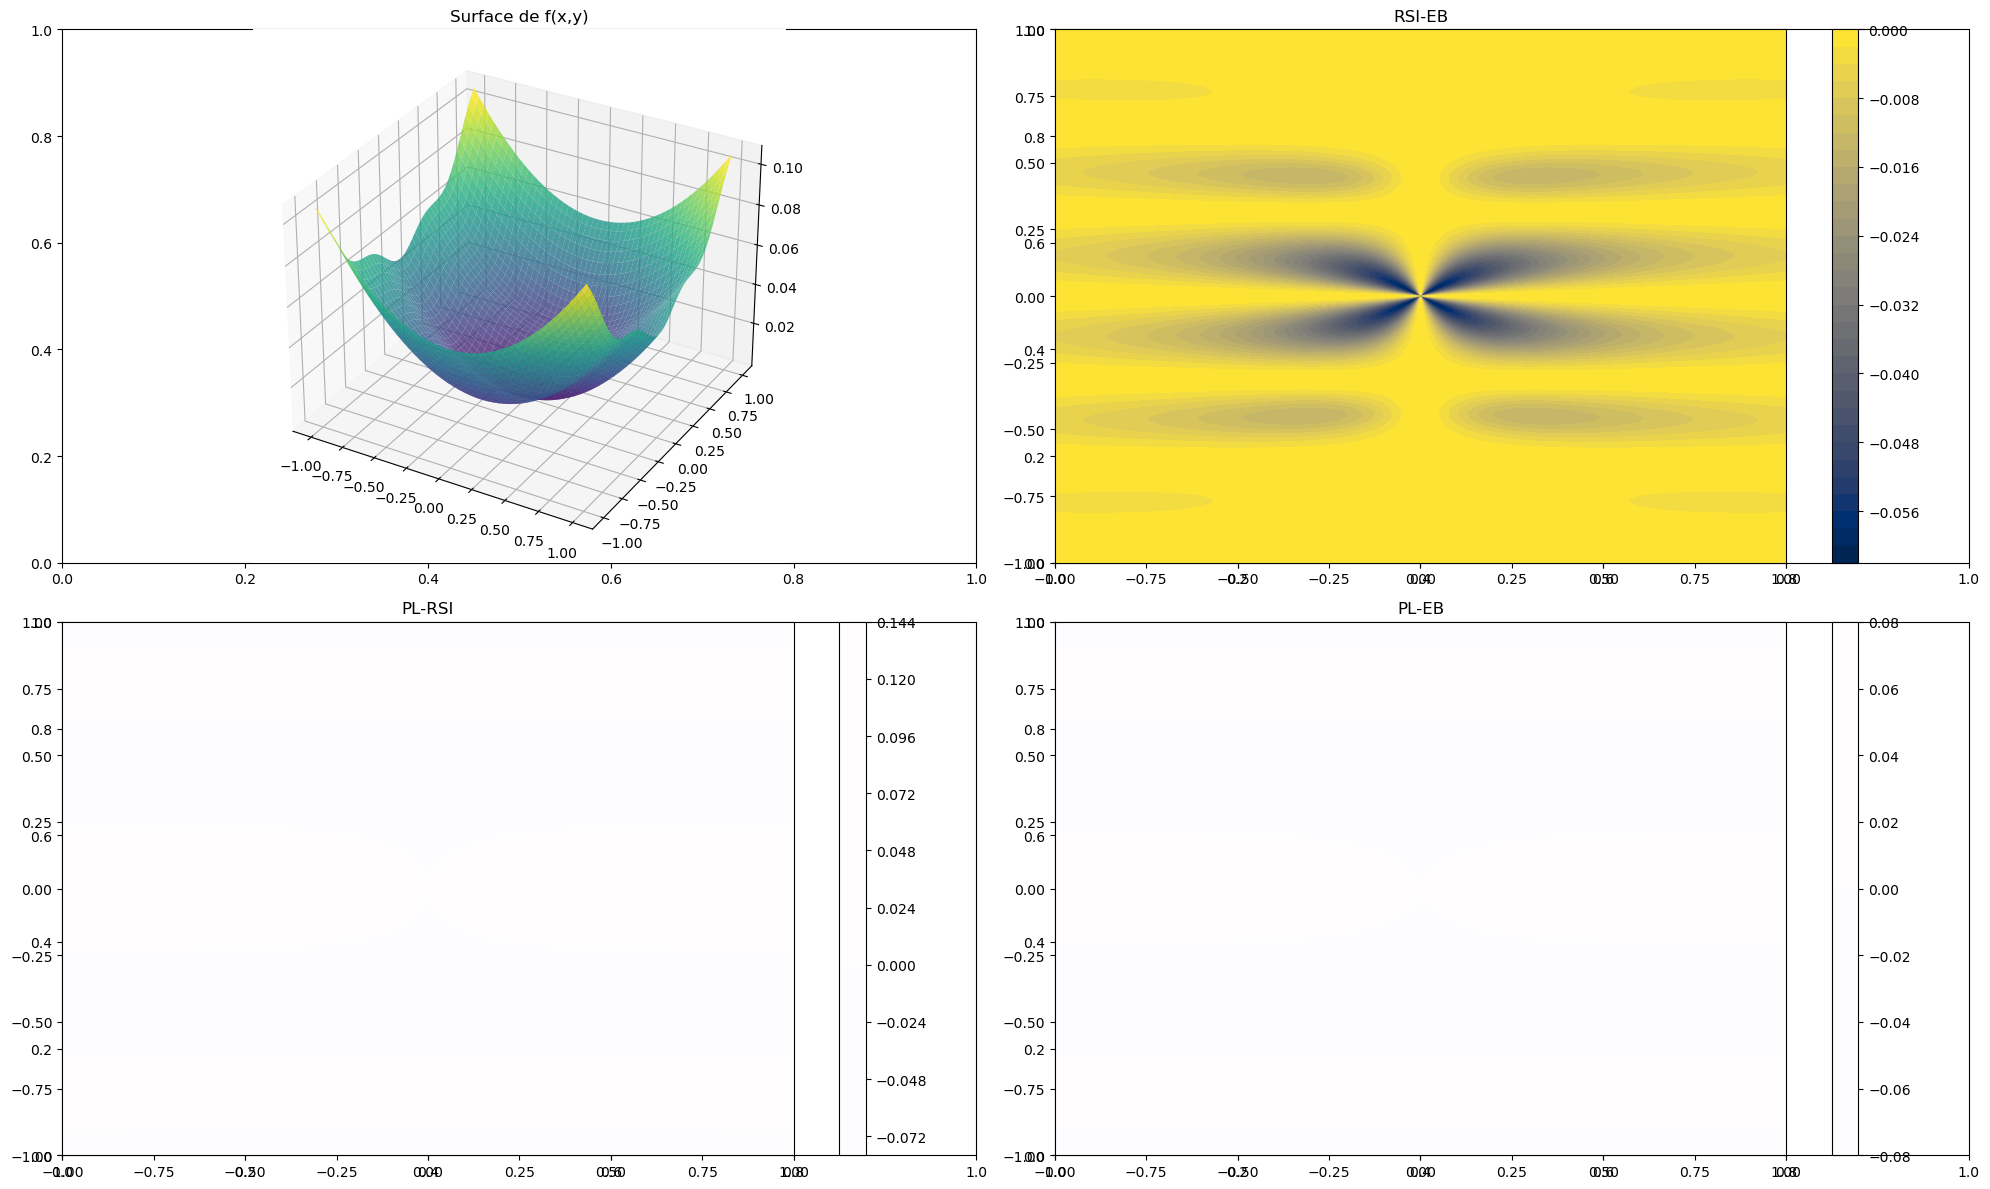

In [17]:
# ---- Test of geometrical cosntant on oscillating quadratic function ------#
# -- Difference between conditions + small curvatur --#
import matplotlib.colors as mcolors
# --- Fonction quadratique ---
def f(x, y,mu,L,alpha,beta):
    return 0.5*mu*x**2 + 0.5*L*y**2 + 0.5*alpha*np.sin(beta*y)**2  # Hessienne diag(2,4) > 0

# --- Gradient ---
def grad_f(x, y,mu,L,alpha,beta):
    return np.array([mu*x, L*y + alpha*beta*np.sin(beta*y)*np.cos(beta*y)])

# --- Grille de points ---
x_vals = np.linspace(-1, 1, 1000)
y_vals = np.linspace(-1, 1, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
mu = 1*10**(-1)
L = 10**(-1)
alpha = 0.015
beta = 5
# Valeurs de la fonction
Z = f(X, Y,mu,L,alpha,beta)

# Gradient sur la grille
U, V = grad_f(X, Y,mu,L,alpha,beta)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / norm_x2[mask]

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
print("PL :",Q2.min(), "RSI :", Q1.min(), "EB :", Q3.min())
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

# Surface f(x,y)
ax1 = fig.add_subplot(2,2,1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax1.set_title("Surface de f(x,y)")

ax2 = fig.add_subplot(2,2,2)
Z = np.array([-20,0,20])
divnorm = mcolors.TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
im1 = ax2.contourf(X, Y, Q1-Q3, levels=30, cmap="cividis")
ax2.set_title("RSI-EB")
fig.colorbar(im1, ax=ax2)

ax3 = fig.add_subplot(2,2,3)
im2 = ax3.contourf(X, Y, Q2-Q1, levels=30, cmap="seismic", norm=divnorm, origin="lower")
ax3.set_title("PL-RSI")
fig.colorbar(im2, ax=ax3)

# ax4 = fig.add_subplot(2,2,4)
# ax4.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
# ax4.quiver(X, Y, U, V, color="red")
# ax4.set_title("Champ de gradient de f")
ax4 = fig.add_subplot(2,2,4)
im3 = ax4.contourf(X, Y, Q2-Q3, levels=30, cmap="seismic", norm=divnorm, origin="lower")
ax4.set_title("PL-EB")
fig.colorbar(im3, ax=ax4)

plt.tight_layout()
plt.show()

PL : 0.03760390021979999 Angle : 0.0002927351475086104 EB : 0.05129315086538839


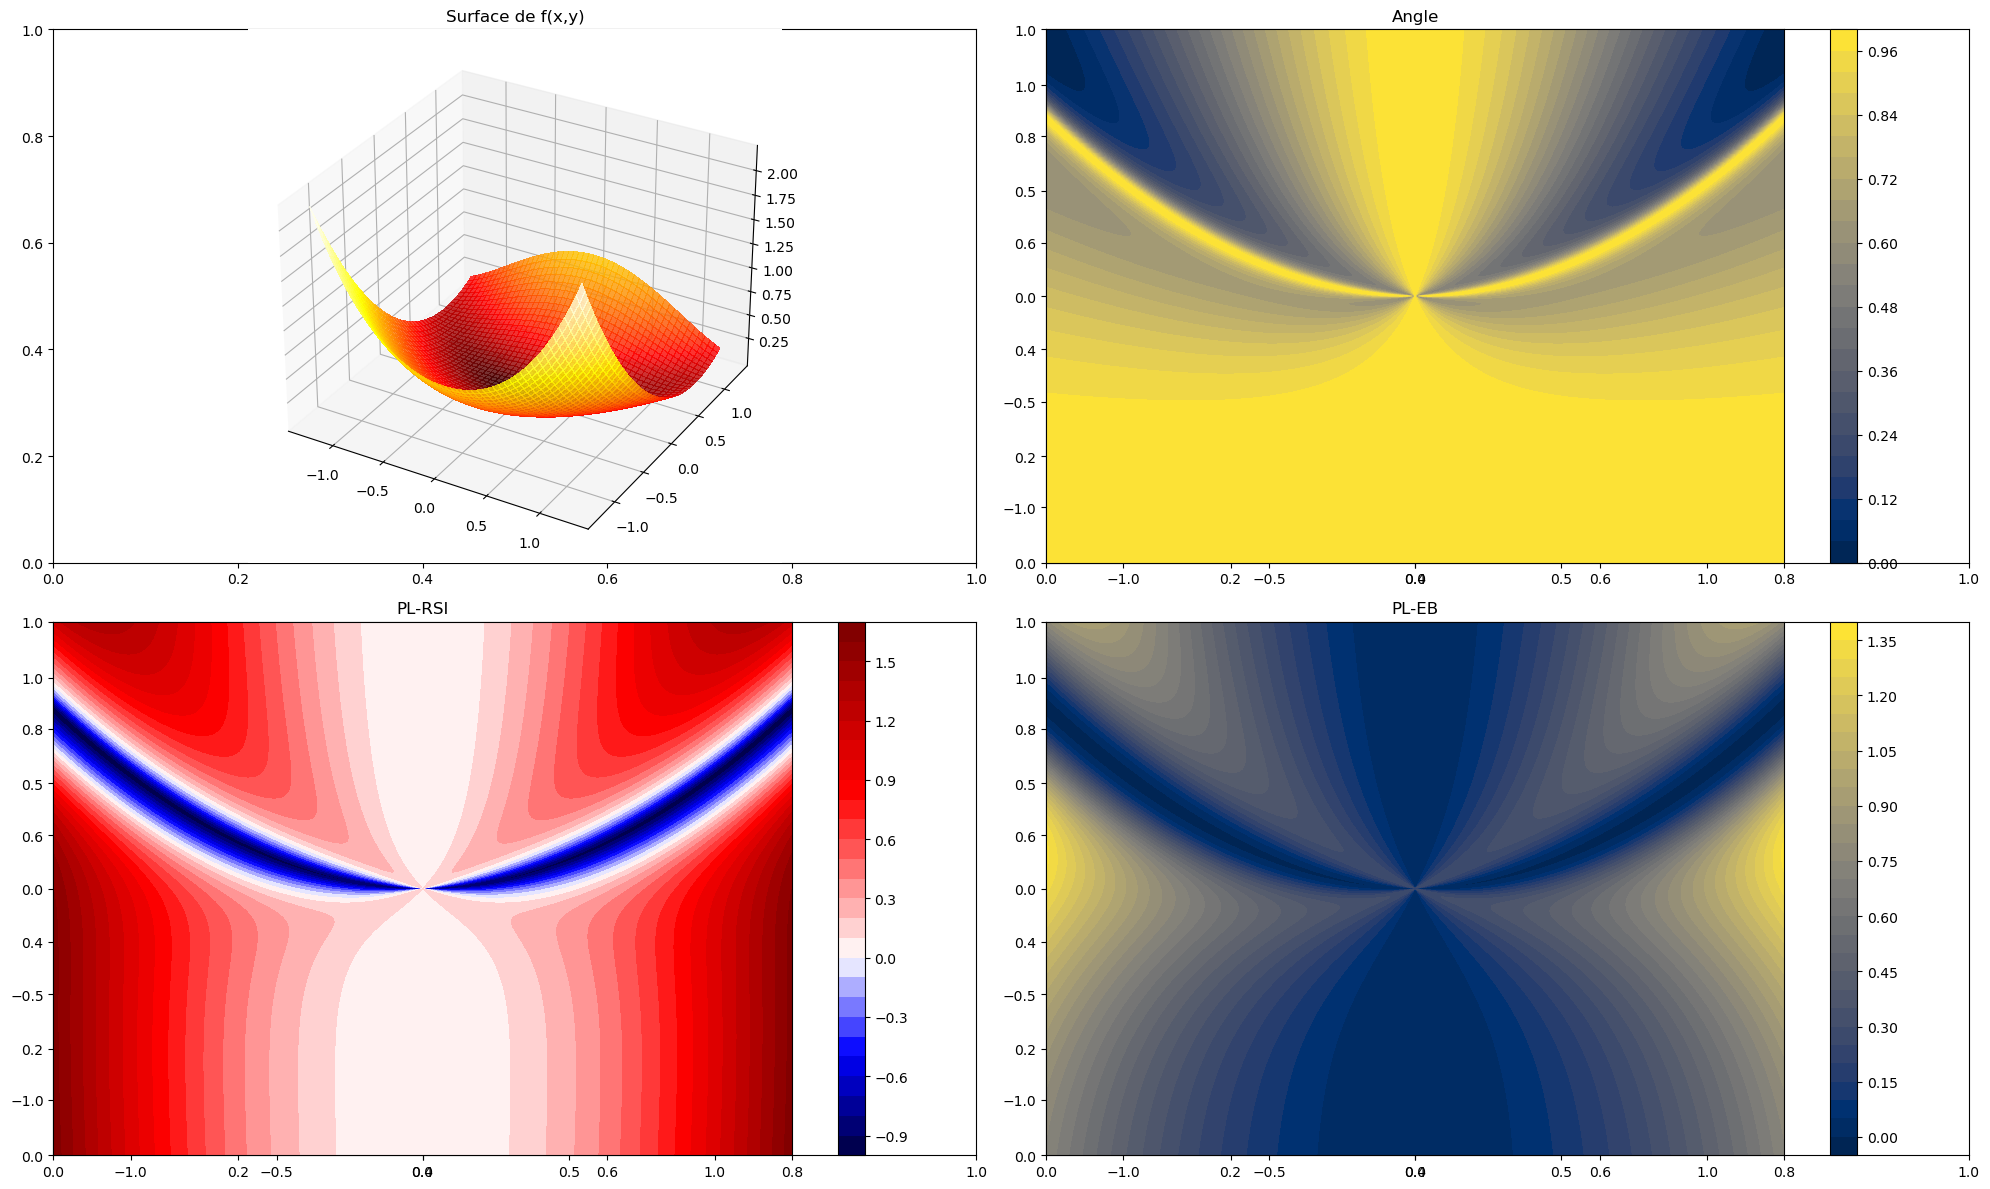

In [12]:
### --- TEST FUNCTION PL BETTER RSI --- ###
def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])
bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 1000)
y_vals = np.linspace(-bound_square, bound_square, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
# Gradient sur la grille
U, V = grad_g(X, Y,epsilon)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / (np.sqrt(norm_x2[mask])*np.sqrt(norm_grad2[mask]))

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
print("PL :",Q2.min(), "Angle :", Q1.min(), "EB :", Q3.min())
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

# Surface f(x,y)
ax1 = fig.add_subplot(2,2,1, projection="3d")

norm = PowerNorm(gamma=0.4, vmin=Z.min(), vmax=Z.max()) 
ax1.plot_surface(X, Y, Z, cmap="hot", alpha=0.8,antialiased=False,norm=norm)
# ax1.contour(X, Y, Z)
ax1.set_title("Surface de f(x,y)")

ax2 = fig.add_subplot(2,2,2)
# Z = np.array([-20,0,20])
# divnorm = mcolors.TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
im1 = ax2.contourf(X, Y, Q1, levels=30, cmap="cividis")
ax2.set_title("Angle")
fig.colorbar(im1, ax=ax2)

ax3 = fig.add_subplot(2,2,3)
divnorm = mcolors.TwoSlopeNorm(vmin=(Q2-Q1).min(), vcenter=0, vmax=(Q2-Q1).max())
im2 = ax3.contourf(X, Y, Q2-Q1, levels=30, cmap="seismic", norm=divnorm, origin="lower")
ax3.set_title("PL-RSI")
fig.colorbar(im2, ax=ax3)

# ax4 = fig.add_subplot(2,2,4)
# ax4.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
# ax4.quiver(X, Y, U, V, color="red")
# ax4.set_title("Champ de gradient de f")
ax4 = fig.add_subplot(2,2,4)
im3 = ax4.contourf(X, Y, Q2-Q3, levels=30, cmap="cividis")
ax4.set_title("PL-EB")
fig.colorbar(im3, ax=ax4)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Simplest default with labels')

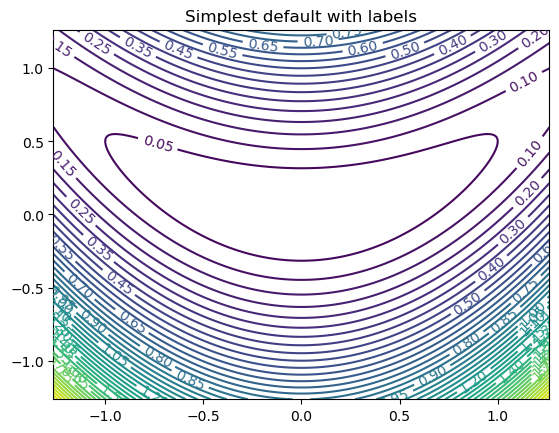

In [15]:
fig, ax = plt.subplots()
CS = ax.contour(X, Y, Z,levels= 50)
ax.clabel(CS, fontsize=10)
ax.set_title('Simplest default with labels')

In [114]:
### --- FOR PLOT --- ###
def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])

   
# bound_square = 1.2
bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 1000)
y_vals = np.linspace(-bound_square+0.6, bound_square, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
# Gradient sur la grille
U, V = grad_g(X, Y,epsilon)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / norm_x2[mask]

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
print("PL :",Q2.min(), "RSI :", Q1.min(), "EB :", Q3.min())
# --- Affichage ---
# fig, ax = plt.subplots(2, 2, figsize=(20, 12))

fig1 = plt.figure()
fontsize =12
ax1 = fig1.add_subplot(111, projection="3d")
norm = PowerNorm(gamma=0.6, vmin=Z.min(), vmax=Z.max()) 
ax1.view_init(elev=30, azim=-60)
ax1.scatter3D(0,0,0,label =":  Unique Minimizer",color="black",marker="x",s=100,  depthshade=False)
ax1.plot_surface(X, Y, Z, cmap="hot", alpha=0.8,antialiased=False,norm=norm)
# ax1.set_title("Surface de f(x,y)")

ax1.set_zticks([])
ax1.set_xticks([-1,1])
ax1.set_yticks([-0.2,1])
ax1.set_xlabel(r'$x$',labelpad=-10)
ax1.set_ylabel(r'$y$',labelpad=-10)
ax1.set_zlabel(r'$f(x,y)$',labelpad=-10)
ax1.legend(edgecolor=(1,1,1),fontsize=fontsize,handletextpad=-0.1)
fig1.tight_layout()
fig1.savefig("figures/surface_fx_y.png", dpi=300)
plt.close(fig1)  # ferme la figure après sauvegarde
divnorm = mcolors.TwoSlopeNorm(vmin=(Q2/Q1).min(), vcenter=1, vmax=(Q2/Q1).max())
# --- Deuxième plot : contour Angle ---
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
im1 = ax2.contourf(X, Y, Q2/Q1, levels=30, cmap="viridis", norm=mcolors.LogNorm(vmin=(Q2/Q1).min(), vmax=(Q2/Q1).max()), origin="lower")
# ax2.set_xticks([-bound_square,bound_square])
# ax2.set_yticks([-bound_square,bound_square])
ax2.set_xticks([-1,1])
ax2.set_yticks([-1,1])
ax2.set_title(r'$\log(\mu(x)/RSI(x))$')
fig2.colorbar(im1, ax=ax2)
fig2.tight_layout()
fig2.savefig("figures/angle.png", dpi=300)
plt.close(fig2)
plt.tight_layout()
plt.show()

PL : 0.037603185761303275 RSI : 9.250482384398365e-05 EB : 0.05129199240236715


<Figure size 640x480 with 0 Axes>

In [1]:
def g(x, y,epsilon):
    return 0.5*(0.5*x**2 - y)**2 + 0.5*epsilon *x**2

# --- Gradient ---
def grad_g(x, y,epsilon):
    return np.array([x*(0.5*x**2 - y)+epsilon*x, -(0.5*x**2 - y)])

# --- Hessian ---
def L_smooth(x, y,epsilon):
    hess_matrix = np.array([[3/2*x**2+epsilon, -x],[-x,1]])  
    L = np.max(np.abs(np.linalg.eig(hess_matrix)[0]))
    return L
bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 1000)
y_vals = np.linspace(-bound_square, bound_square, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
# Gradient sur la grille
U, V = grad_g(X, Y,epsilon)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2
gamma = 0.001
# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
gamma = np.linspace(1*10**-6,0.002,1000)
gf_bound = np.empty(1000)
nmo_bound = np.empty(1000)
gd_bound = np.empty(1000)
nm_bound = np.empty(1000)
k = 0
for i in gamma:
    Q1[mask] = -2*(Z[mask]- i**(-1)*inner_prod[mask]) / norm_x2[mask]
    gf_bound[k] = i*Q1.min()
    nmo_bound[k] = i*np.sqrt(Q1.min())
    gd_bound[k] = i*Q1.min()/L
    nm_bound[k] = i*np.sqrt(Q1.min()/L)
    k+=1
# plt.contourf(X, Y, Q1, levels=30, cmap="cividis")
print(np.nanmax(gd_bound),np.nanmax(nm_bound))

NameError: name 'np' is not defined

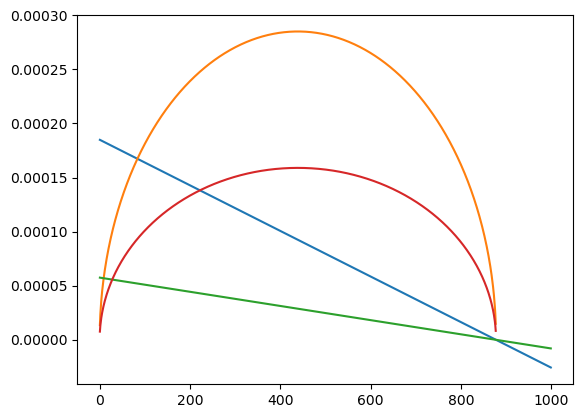

In [134]:
plt.plot(gf_bound)
plt.plot(nmo_bound)
plt.plot(gd_bound)
plt.plot(nm_bound)

In [136]:
0.0376039002197999/2

0.01880195010989995

In [ ]:
def h(r):
    return 0.5*r**2  # décroissance radiale

def g(u, v):
    nb_f = 10
    a = 10*nprand.rand(nb_f)
    c = 50*nprand.rand(nb_f)
    b = nprand.normal(0,10,10)
    d = nprand.normal(0,10,10)
    return_var = 0
    for i in range(nb_f):
        return_var += a[i]*np.sin(b[i]*u)**2 + c[i]*np.cos(d[i]*u)**2
    return return_var/nb_f +1  # dépend uniquement de la direction

def f(x, y):
    r = np.sqrt(x**2 + y**2)
    # éviter la division par zéro
    u = np.where(r != 0, x/r, 0.0)
    v = np.where(r != 0, y/r, 0.0)
    return h(r) * g(u, v)

bound_square = 1.2638
x_vals = np.linspace(-bound_square, bound_square, 1000)
y_vals = np.linspace(-bound_square, bound_square, 1000)
X, Y = np.meshgrid(x_vals, y_vals)
epsilon = 0.1

Z = g(X, Y,epsilon)
# Gradient sur la grille
U, V = grad_g(X, Y,epsilon)

# Norme de x et de grad f
norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

# --- Quantités demandées ---
# <grad_f(x), x> = U*X + V*Y
inner_prod = U*X + V*Y

Q1 = np.zeros_like(X)
Q2 = np.zeros_like(X)
Q3 = np.zeros_like(X)
# # Éviter division par zéro
# mask = norm_x2 > 1e-12
# Q1[mask] = inner_prod[mask] / norm_x2[mask]

# mask = Z > 1e-12
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# Éviter division par zéro
mask = norm_x2 > 1e-12
Q1[mask] = inner_prod[mask] / (np.sqrt(norm_x2[mask])*np.sqrt(norm_grad2[mask]))

mask = Z > 1e-12
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

mask = Z > 1e-12
Q3[mask] =np.sqrt(norm_grad2[mask] / norm_x2[mask])
print("PL :",Q2.min(), "Angle :", Q1.min(), "EB :", Q3.min())
# --- Affichage ---
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

# Surface f(x,y)
ax1 = fig.add_subplot(2,2,1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
# ax1.contour(X, Y, Z)
ax1.set_title("Surface de f(x,y)")

ax2 = fig.add_subplot(2,2,2)
# Z = np.array([-20,0,20])
# divnorm = mcolors.TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
im1 = ax2.contourf(X, Y, Q1, levels=30, cmap="cividis")
ax2.set_title("Angle")
fig.colorbar(im1, ax=ax2)

ax3 = fig.add_subplot(2,2,3)
divnorm = mcolors.TwoSlopeNorm(vmin=(Q2-Q1).min(), vcenter=0, vmax=(Q2-Q1).max())
im2 = ax3.contourf(X, Y, Q2-Q1, levels=30, cmap="seismic", norm=divnorm, origin="lower")
ax3.set_title("PL-RSI")
fig.colorbar(im2, ax=ax3)

# ax4 = fig.add_subplot(2,2,4)
# ax4.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
# ax4.quiver(X, Y, U, V, color="red")
# ax4.set_title("Champ de gradient de f")
ax4 = fig.add_subplot(2,2,4)
im3 = ax4.contourf(X, Y, Q2-Q3, levels=30, cmap="cividis")
ax4.set_title("PL-EB")
fig.colorbar(im3, ax=ax4)

plt.tight_layout()
plt.show()